# Импорт библиотек

In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from catboost import CatBoostClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt

# 1. Базовые модели
Logistic Regression, Random Forest, CatBoost

In [2]:
df = pd.read_csv('../data/heart.csv')

X = df.drop(columns='HeartDisease')
y = df['HeartDisease']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

# медианы только по train
medians = {col: X_train[col].replace(0, np.nan).median()
           for col in ['Cholesterol', 'RestingBP']}

def clean(part):
    part = part.copy()
    for col in ['Cholesterol', 'RestingBP']:
        part[col] = part[col].replace(0, np.nan).fillna(medians[col])
    part['Oldpeak'] = part['Oldpeak'].clip(lower=0)
    return part

def encode(part):
    part = part.copy()
    part['Sex'] = (part['Sex'] == 'M').astype(int)
    part['ExerciseAngina'] = (part['ExerciseAngina'] == 'Y').astype(int)
    part['ST_Slope'] = part['ST_Slope'].map({'Up': 0, 'Flat': 1, 'Down': 2})
    return pd.get_dummies(part, columns=['ChestPainType', 'RestingECG'],
                          drop_first=True, dtype=int)

X_train = encode(clean(X_train))
X_test = encode(clean(X_test))
X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

num_cols = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

print(X_train.shape, X_test.shape)

(734, 14) (184, 14)


In [3]:
models = {
    'LogReg': LogisticRegression(max_iter=1000, random_state=42),
    'RandomForest': RandomForestClassifier(n_estimators=100, random_state=42),
    'CatBoost': CatBoostClassifier(iterations=200, depth=4, learning_rate=0.1,
                                   random_seed=42, verbose=False),
}

rows = []
for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]
    rows.append({
        'model': name,
        'accuracy': accuracy_score(y_test, pred),
        'precision': precision_score(y_test, pred),
        'recall': recall_score(y_test, pred),
        'f1': f1_score(y_test, pred),
        'roc_auc': roc_auc_score(y_test, proba),
    })

test_df = pd.DataFrame(rows).round(3)
test_df

,model,accuracy,precision,recall,f1,roc_auc
0,LogReg,0.870,0.861,0.912,0.886,0.907
1,RandomForest,0.870,0.890,0.873,0.881,0.933
2,CatBoost,0.864,0.889,0.863,0.876,0.920


### Выводы по базовым моделям на тесте

1. Все три модели дают 86–87% accuracy против 55.3%
   у константного прогноза большинства.
2. **LogReg:** лучший recall (0.912) и F1 (0.886) - пропускает меньше всего
   больных, но чаще ложно тревожится (precision 0.861) и хуже всех ранжирует
   риск (ROC-AUC 0.907).
3. **CatBoost:** на дефолтных параметрах стабильно чуть ниже RF по всем
   метрикам - преимуществ не дал.
4. **RandomForest:** лучший ROC-AUC (0.933) и precision (0.890) при том же
   accuracy (0.870). Отставание по F1 всего 0.005 (~1 объект из 184) -
   статистически незначимо.

   **RandomForest** - лучшая различающая способность и
   точность положительных прогнозов. recall (0.873).

In [4]:
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

cv_rows = []
for name, model in models.items():
    scores = cross_validate(model, X_train, y_train, cv=5, scoring=scoring)
    cv_rows.append({'model': name,
                    **{m: scores[f'test_{m}'].mean() for m in scoring}})

cv_df = pd.DataFrame(cv_rows).round(3)
cv_df

,model,accuracy,precision,recall,f1,roc_auc
0,LogReg,0.845,0.855,0.867,0.861,0.911
1,RandomForest,0.853,0.849,0.894,0.870,0.918
2,CatBoost,0.857,0.864,0.882,0.872,0.923


### Выводы: кросс-валидация и сравнение с тестом

1. **Устойчивость:** разрыв CV - test по всем метрикам <= 0.025 -
   переобучения нет, модели обобщают стабильно.
2. **На CV модели почти равны:** CatBoost формально лидирует по
   accuracy/f1/ROC-AUC (0.857/0.872/0.923), RandomForest - по recall (0.894).
   различия <= 0.005, т.е. в пределах шума.
3. **Тест:** RF лучший по ROC-AUC (0.933) и precision (0.890),
   LogReg - по recall (0.912). CatBoost стабилен посередине.
4. **Явного победителя на дефолтах нет** - выбор финальной модели возможен после
   после подбора гиперпараметров.
5. **Кандидат - RandomForest** - лучший CV-recall (0.894,
   медицински важный) и лучший тестовый ROC-AUC.
   CatBoost - резервный и кандидат.

# 2. Сравнение метрик, подбор гиперпараметров (GridSearchCV/RandomizedSearchCV) для лучшей модели.

In [5]:
# сетка параметров - не слишком большая, чтобы считалось быстро
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, None],
    'min_samples_leaf': [1, 2, 4],
    'min_samples_split': [2, 5, 10],
    'class_weight': [None, 'balanced']
}

rf_base = RandomForestClassifier(random_state=42)

grid = GridSearchCV(
    rf_base,
    param_grid,
    scoring='f1',           # оптимизируем F1, т.к. классы несбалансированы
    cv=5,
    n_jobs=-1,              # параллельно на всех ядрах
    verbose=1
)

grid.fit(X_train, y_train)

print('Лучшие параметры:', grid.best_params_)
print('Лучший F1 на CV:', round(grid.best_score_, 3))

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Лучшие параметры: {'class_weight': None, 'max_depth': 15, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 300}
Лучший F1 на CV: 0.884


### Выводы: подбор гиперпараметров

1. **GridSearchCV:** 216 комбинаций, 1080 фитов. лучший CV F1 = 0.884
   против 0.870 у дефолтов - тюнинг дал +0.014 на кросс-валидации.
2. **Лучшие параметры:** n_estimators=300, max_depth=15, min_samples_leaf=2,
   min_samples_split=5, class_weight=None.
3. **class_weight=None:** балансировка классов отвергнута самой сеткой -
   при дисбалансе 55/45 она ухудшает precision/F1. Пробовали - проверили - отказались.
4. **Регуляризация:** глубокие деревья (15) с лёгкими ограничениями
   (leaf=2, split=5) - защита от переобучения без потери качества.
5. **n_estimators у границы сетки:** рост числа деревьев ещё даёт прирост -
   кандидат на следующую итерацию улучшения.

Из-за несбалансированности классов целесообразнее использовать F1, чем Accuracy

In [6]:
# базовая модель (дефолты)
rf_before = RandomForestClassifier(n_estimators=100, random_state=42)
rf_before.fit(X_train, y_train)

# тюнингованная модель
rf_after = grid.best_estimator_

# метрики на тесте
rows = []
for name, model in [('RF до тюнинга', rf_before), ('RF после тюнинга', rf_after)]:
    pred = model.predict(X_test)
    proba = model.predict_proba(X_test)[:, 1]
    rows.append({
        'model': name,
        'accuracy': accuracy_score(y_test, pred),
        'precision': precision_score(y_test, pred),
        'recall': recall_score(y_test, pred),
        'f1': f1_score(y_test, pred),
        'roc_auc': roc_auc_score(y_test, proba),
    })

compare_df = pd.DataFrame(rows).round(3)
compare_df

,model,accuracy,precision,recall,f1,roc_auc
0,RF до тюнинга,0.87,0.890,0.873,0.881,0.933
1,RF после тюнинга,0.88,0.892,0.892,0.892,0.932


### Выводы: подбор гиперпараметров, подтверждение на тесте

1. **F1 на тесте: 0.881 - 0.892 (+0.011), accuracy 0.87 - 0.88** -
   улучшение с CV (0.870 - 0.884) подтвердилось на отложенной выборке.
2. **Главный выигрыш - recall: 0.873 - 0.892 (+0.019):**
   модель стала пропускать меньше больных, что критично с медицинской точки зрения.
3. **Precision = Recall = F1 = 0.892:** баланс ложных результатов и пропусков.
4. **ROC-AUC стабилен (0.933 - 0.932):** тюнинг улучшил границу решения,
   а не ранжирование риска.
5. **CV ~ test (0.884 и 0.892):** переобучения под кросс-валидацию нет.
6. **Финальная модель проекта - тюнингованный RandomForest:**
   лучший тестовый F1 среди всех кандидатов. LogReg выигрывает только
   по recall (0.912), но за счёт precision (0.861).

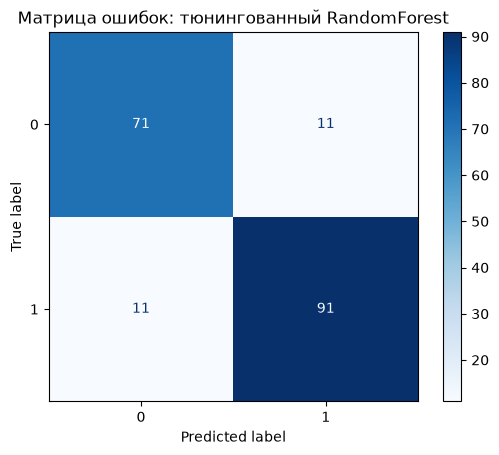

In [7]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, rf_after.predict(X_test))
ConfusionMatrixDisplay(cm).plot(cmap='Blues')
plt.title('Матрица ошибок: тюнингованный RandomForest')
plt.show()

### Выводы: матрица ошибок тюнингованного RandomForest (п. 1.b.vii)

1. **Структура:** TN=71, FP=11, FN=11, TP=91 (всего 184).
   цифры точно воспроизводят метрики таблицы (acc 0.88, P=R=F1 0.892).
2. **Ошибки симметричны (FP = FN = 11):** модель не перекошена
   ни в сторону паники, ни в сторону пропусков.
3. **FN = 11 (11% больных):** главная цена модели и точка роста -
   порог классификации можно сдвинуть, чтобы жертвовать FP ради снижения FN.
4. **FP = 11:** ложные тревоги допустимы для скрининга:
   перепроверить здорового дешевле, чем пропустить больного.
5. **Итог:** 88% верных диагнозов, баланс ошибок осознанный -
   модель пригодна как финальная для проекта.

### 3. Анализ важности признаков

Лучшие параметры GridSearchCV:
  class_weight: None
  max_depth: 15
  min_samples_leaf: 2
  min_samples_split: 5
  n_estimators: 300


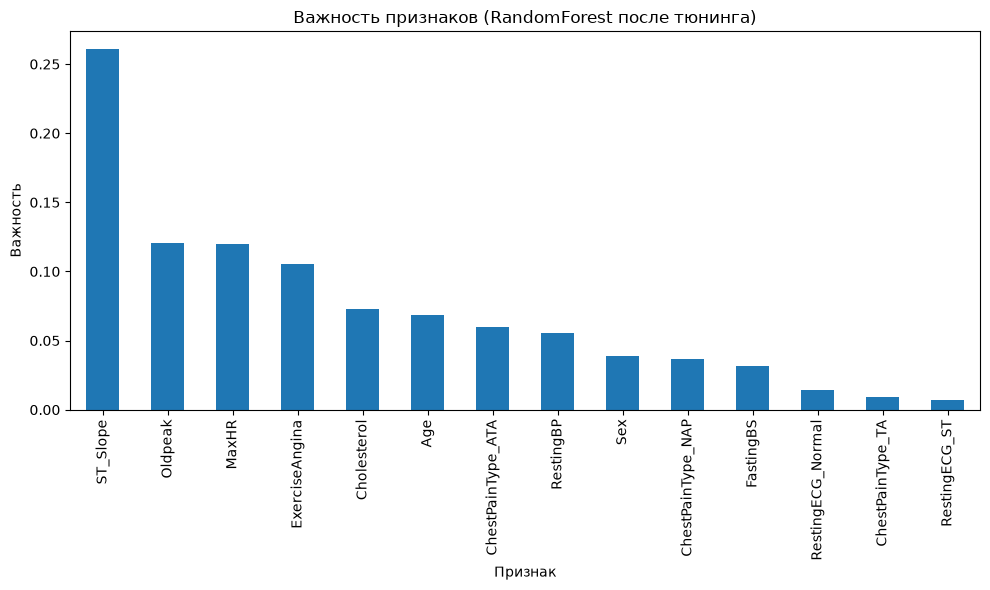

In [8]:
# лучшие параметры
print('Лучшие параметры GridSearchCV:')
for param, value in grid.best_params_.items():
    print(f'  {param}: {value}')

# важность признаков
importances = pd.Series(rf_after.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(10, 6))
importances.plot(kind='bar')
plt.title('Важность признаков (RandomForest после тюнинга)')
plt.ylabel('Важность')
plt.xlabel('Признак')
plt.tight_layout()
plt.show()

### Выводы: важность признаков

1. **Топ-4 = ~60% важности:** ST_Slope (0.26), Oldpeak (0.12),
   MaxHR (0.12), ExerciseAngina (0.11).
2. **ST_Slope - лидер, находка модели:** признак категориальный и не попал
   в корреляционную матрицу EDA - его силу выявил только RandomForest.
3. **Гипотеза EDA подтверждена:** Oldpeak и MaxHR в топе важности,
   как и предсказывали корреляции (+0.40 / −0.40).
4. **Слабые признаки:** RestingECG-дамми (<=0.013), ChestPainType_TA (0.008),
   Sex (0.038) - кандидаты на отбор признаков в следующей итерации.